<h1>MULTIPLE LINEAR REGRESSION</h1>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.shape

(1436, 11)

In [5]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [8]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
le

LabelEncoder()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

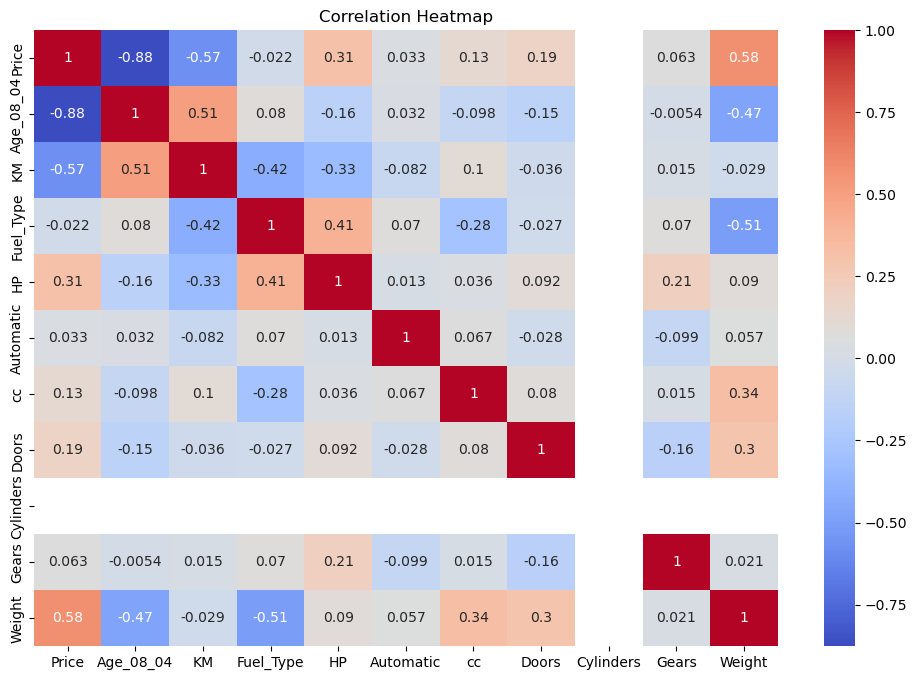

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

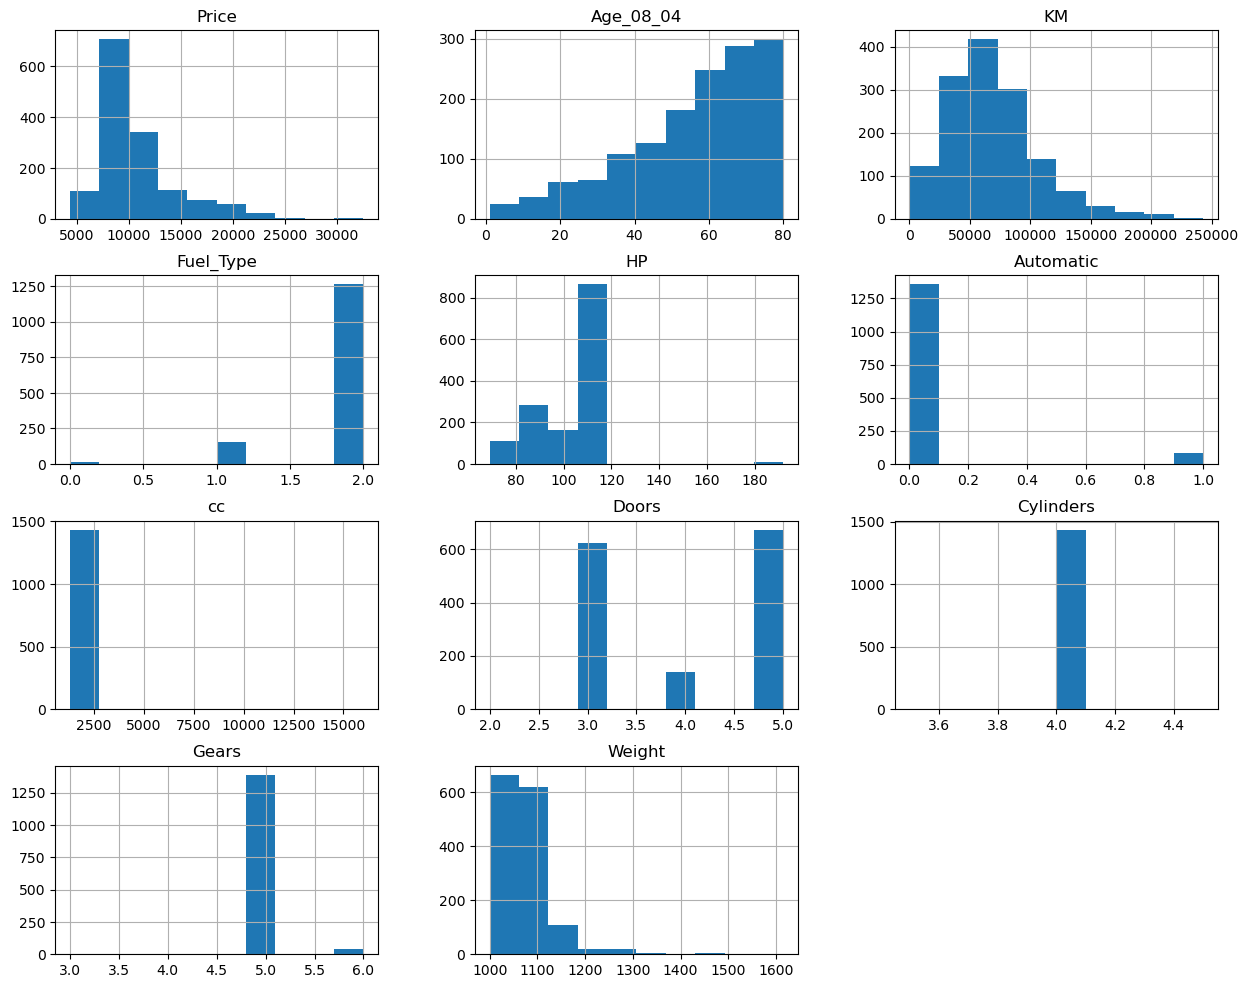

In [13]:
df.hist(figsize=(15,12))
plt.show()

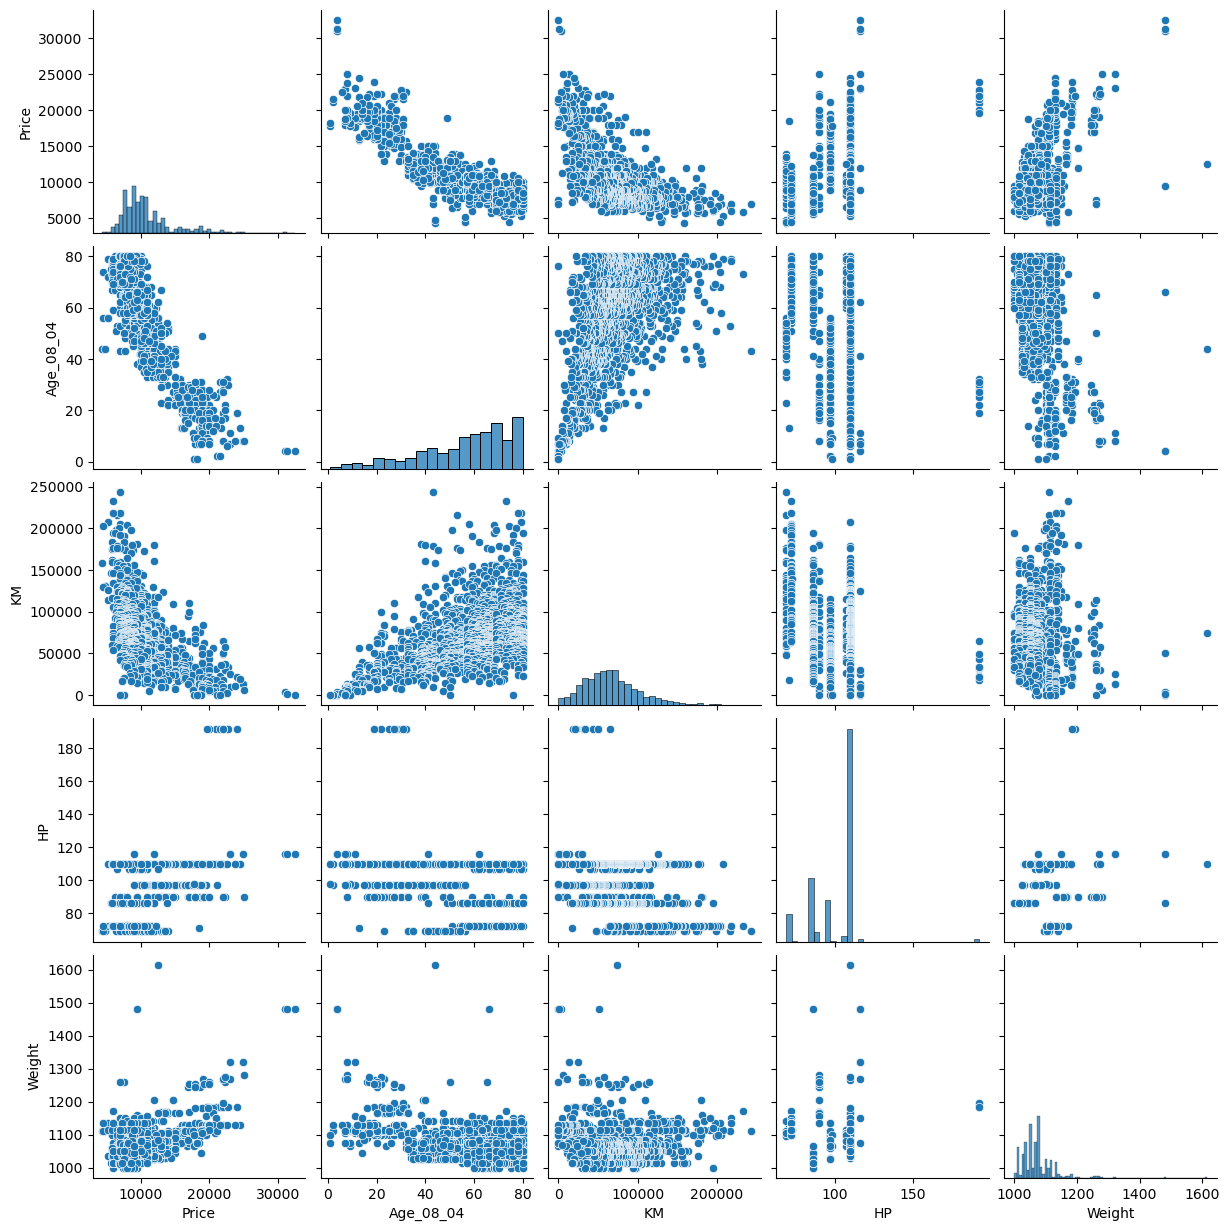

In [14]:
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

In [15]:
X = df[['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight']]
Y = df['Price']

In [23]:
from sklearn.model_selection import train_test_split

X_train , X_test , Y_train , Y_test = train_test_split( X , Y , test_size =0.2, random_state=42)

<h6>Model 1: Using All Features</h6>

In [25]:
from sklearn.linear_model import LinearRegression

# Model 1
model1 = LinearRegression()

# Train model
model1.fit(X_train, Y_train)

# Prediction
Y_pred1 = model1.predict(X_test)

# Coefficients
coeff1 = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})

print(coeff1)
print("Intercept:", model1.intercept_)

     Feature   Coefficient
0  Age_08_04 -1.214362e+02
1         KM -1.693560e-02
2  Fuel_Type  8.620564e+02
3         HP  2.065828e+01
4  Automatic  2.451969e+02
5         cc -7.351539e-02
6      Doors -3.627965e+01
7  Cylinders -6.821210e-13
8      Gears  5.302820e+02
9     Weight  2.351064e+01
Intercept: -12636.27811238473


<h6>Model 2: Selected Important Features</h6>

In [26]:
# Selecting important features
X2 = df[['Age_08_04', 'HP', 'Weight']]

# Split dataset
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, Y,
    test_size=0.2,
    random_state=42
)

# Build model
model2 = LinearRegression()

# Train model
model2.fit(X2_train, Y2_train)

# Prediction
Y_pred2 = model2.predict(X2_test)

# Coefficients
coeff2 = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model2.coef_
})

print(coeff2)
print("Intercept:", model2.intercept_)

     Feature  Coefficient
0  Age_08_04  -144.453567
1         HP    42.732677
2     Weight    15.418102
Intercept: -2051.962665430894


<h6>Model 3: Another Combination of Features</h6>

In [27]:
# Different feature combination
X3 = df[['KM', 'HP', 'cc', 'Doors', 'Weight']]

# Split dataset
X3_train, X3_test, Y3_train, Y3_test = train_test_split(
    X3, Y,
    test_size=0.2,
    random_state=42
)

# Build model
model3 = LinearRegression()

# Train model
model3.fit(X3_train, Y3_train)

# Prediction
Y_pred3 = model3.predict(X3_test)

# Coefficients
coeff3 = pd.DataFrame({
    'Feature': X3.columns,
    'Coefficient': model3.coef_
})

print(coeff3)
print("Intercept:", model3.intercept_)

  Feature  Coefficient
0      KM    -0.050961
1      HP    21.283469
2      cc    -0.163678
3   Doors   -42.070436
4  Weight    41.292215
Intercept: -31765.046986260673


In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [30]:
## Model 1 Evaluation
mae1 = mean_absolute_error(Y_test, Y_pred1)
mse1 = mean_squared_error(Y_test, Y_pred1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(Y_test, Y_pred1)

print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE :", rmse1)
print("R2 Score :", r2_1)

MAE : 992.8982858371439
MSE : 2096851.1400177074
RMSE : 1448.0508071258091
R2 Score : 0.8428476112018


In [32]:
## Model 2 Evaluation
mae2 = mean_absolute_error(Y2_test, Y_pred2)
mse2 = mean_squared_error(Y2_test, Y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(Y2_test, Y_pred2)

print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE :", rmse2)
print("R2 Score :", r2_2)

MAE : 1093.2552092820204
MSE : 2247515.9953329605
RMSE : 1499.1717697892261
R2 Score : 0.8315557548230361


In [33]:
## Model 3 Evaluation
mae3 = mean_absolute_error(Y3_test, Y_pred3)
mse3 = mean_squared_error(Y3_test, Y_pred3)
rmse3 = np.sqrt(mse3)
r2_3 = r2_score(Y3_test, Y_pred3)

print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE :", rmse3)
print("R2 Score :", r2_3)

MAE : 1572.0337323785034
MSE : 5234216.984939795
RMSE : 2287.8411188148084
R2 Score : 0.6077119224283825


<h5>Apply Ridge Regression</h5>

In [37]:
from sklearn.linear_model import Ridge

In [35]:
# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train, Y_train)

# Prediction
ridge_pred = ridge_model.predict(X_test)

# Evaluation
print("----- Ridge Regression -----")

print("MAE :", mean_absolute_error(Y_test, ridge_pred))
print("MSE :", mean_squared_error(Y_test, ridge_pred))
print("RMSE :", np.sqrt(mean_squared_error(Y_test, ridge_pred)))
print("R2 Score :", r2_score(Y_test, ridge_pred))

----- Ridge Regression -----
MAE : 992.8742553506737
MSE : 2095305.817863376
RMSE : 1447.5171217859138
R2 Score : 0.8429634282301913


In [36]:
#Ridge Coefficients
ridge_coeff = pd.DataFrame({'Feature': X.columns,'Coefficient': ridge_model.coef_})
ridge_coeff

,Feature,Coefficient
0,Age_08_04,-121.416308
1,KM,-0.016972
2,Fuel_Type,851.619534
3,HP,20.780148
4,Automatic,241.303341
5,cc,-0.073842
6,Doors,-36.319996
7,Cylinders,0.000000
8,Gears,518.174870
9,Weight,23.472191


<h5>Apply Lasso Regression</h5>

In [38]:
from sklearn.linear_model import Lasso

# Create Lasso model
lasso_model = Lasso(alpha=1.0)

# Train model
lasso_model.fit(X_train, Y_train)

# Prediction
lasso_pred = lasso_model.predict(X_test)

# Evaluation
print("----- Lasso Regression -----")

print("MAE :", mean_absolute_error(Y_test, lasso_pred))
print("MSE :", mean_squared_error(Y_test, lasso_pred))
print("RMSE :", np.sqrt(mean_squared_error(Y_test, lasso_pred)))
print("R2 Score :", r2_score(Y_test, lasso_pred))

----- Lasso Regression -----
MAE : 992.9143095869038
MSE : 2095598.6166041845
RMSE : 1447.6182565179897
R2 Score : 0.8429414838867533


In [39]:
# Lasso Classification
lasso_coeff = pd.DataFrame({'Feature': X.columns,'Coefficient': lasso_model.coef_})
lasso_coeff

,Feature,Coefficient
0,Age_08_04,-121.372123
1,KM,-0.016993
2,Fuel_Type,849.605132
3,HP,20.831727
4,Automatic,224.725572
5,cc,-0.073285
6,Doors,-35.899141
7,Cylinders,0.000000
8,Gears,501.974246
9,Weight,23.471871
